In [5]:
# Done as part of Sanvi Pal's NB 155 final project, creating a NIH grant draft and contributing to
# repo for "Simulating early steps in nicotine dependence: Pharmacokinetics, activation, and chaperoning of nicotinic receptors"


# Comments from Prof. Lester:
# Its input: Nicotine Web App output .csv files generated by http://inside-out.caltech.edu:9988
# The user places the files in the folder /content/drive/MyDrive/Colab_data/NWA_Data/NWA outputs/
# The input files have a variable time base, depedning on the integrator, the dose table, etc.
# and their length varies, from ~300 to ~ 10 MB.
# Most analysis programs don't treat this correctly.
# The user must make the folder, /content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/
# The routine then places the resampled .txt files in the folder /content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/
# The resampled time base is 0.5 min.
# Some parts require upsampling; others, downsampling. Which is why I've not found a simple routine already written!
# the resampled file ~ 250 kB per day of simulation.
# I import these into Excel, for further analysis.
# Most time series analysis programs handle this correctly.
# For further comments, see Alexander Z, Wang, Janis Jeon, Fulden Buyukozturk, Ryan M. Drenan, and Henry A. Lester
# Mol Pharm 2024.
# Note that the routine wants your to press any key at times.


import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import plotly.graph_objects as go
import plotly.express as px
import csv
# no keyboard import necessary
from scipy.signal import find_peaks, peak_prominences
#HAL runs this on Google Colab:
from google.colab import drive
#This is required to find the data folder, HAL believes
drive.mount('/content/drive')
# !ls -l /content/drive/MyDrive

Mounted at /content/drive


# Normal

In [ ]:
input_file_path= '/content/drive/MyDrive/Colab_data/NWA_Data/NWA outputs/'
input_core_name = 'nicotineapp_40_datatable_28_6min_yr'
input_name = input_file_path + input_core_name
input_full_name = input_file_path + input_core_name + ".csv"
print("the input file will be:")
print (input_full_name)
input("Press the Enter key to continue: ")
#df_sh will be this routine's internal working name for any file we're resampling.
df_sh = pd.read_csv(input_full_name)


the input file will be:
/content/drive/MyDrive/Colab_data/NWA_Data/NWA outputs/nicotineapp_40_datatable_28_6min_yr.csv
Press the Enter key to continue: g


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


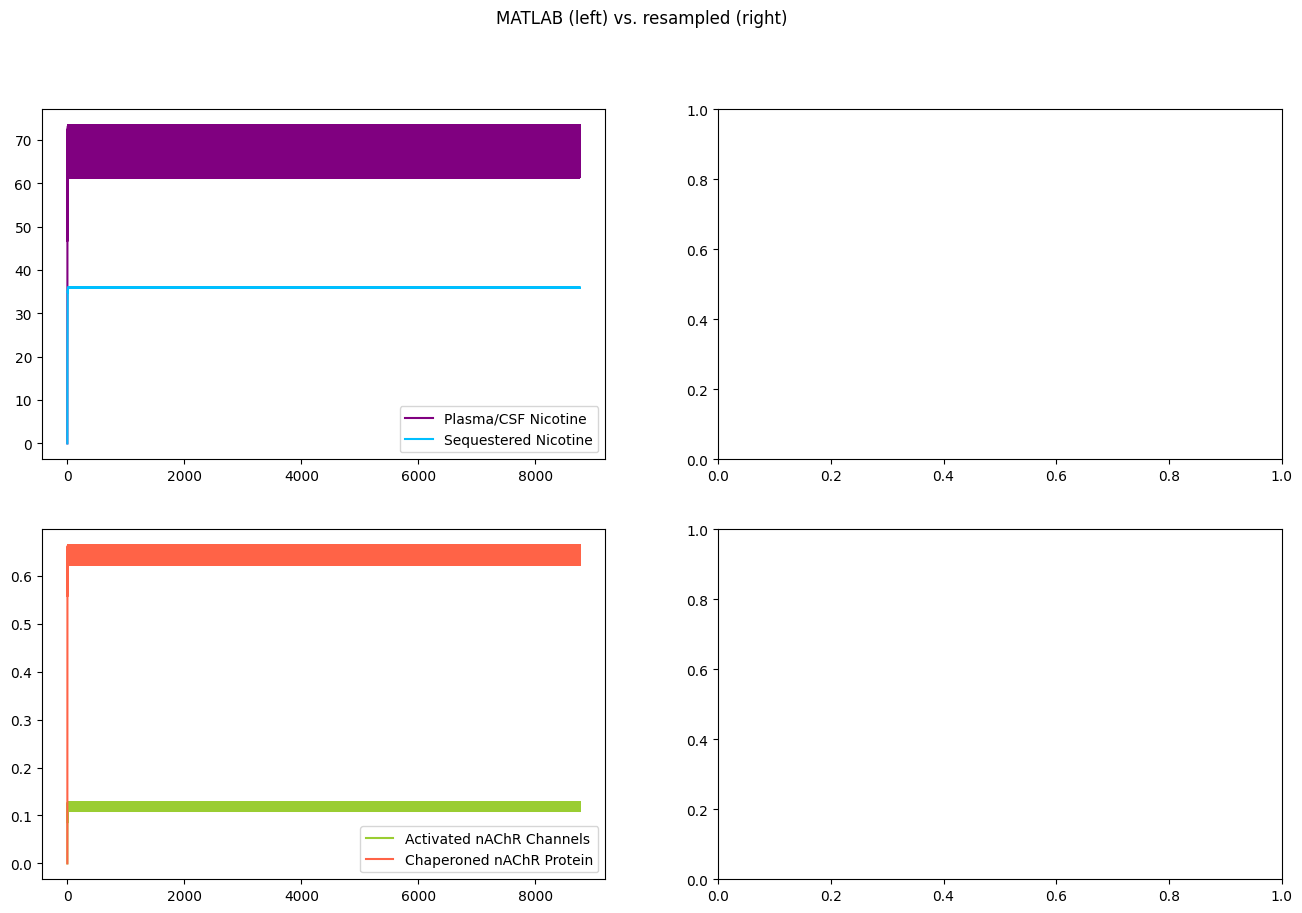

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs[0,0].plot(df_sh['Time'], df_sh['Plasma/ CSF/ ER Nicotine'], label='Plasma/CSF Nicotine', color='purple')
axs[0,0].plot(df_sh['Time'], df_sh['Sequestered Nicotine'], label='Sequestered Nicotine', color='deepskyblue')



axs[1,0].plot(df_sh['Time'], df_sh['Fraction of Activated nAChR'], label='Activated nAChR Channels', color='yellowgreen')
axs[1,0].plot(df_sh['Time'], df_sh['Fraction of Chaperoned nAChR'], label='Chaperoned nAChR Protein', color='tomato')

#we'll have only set of plots.  On the left.
for i in range(2):
    for j in range(2):
        handles, labels = axs[i, j].get_legend_handles_labels()
        if labels:
            axs[i, j].legend()
plt.suptitle('MATLAB (left) vs. resampled (right)')
plt.show()

# HAL's conversion to 0.5 min time interval, 1 min = 1/60 h

In [ ]:
import numpy as np
import pandas as pd
import os
from scipy.ndimage import gaussian_filter1d

# sanvi: main changes are rolling.mean() before resampling, spline interpolation, gaussian filter to smooth more


output_file_path = '/content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/'
output_core_name = "input_core_name"  # Replace with actual input name
output_full_name = os.path.join(output_file_path, f"{output_core_name}_resampled_HAL.txt")

if os.path.exists(output_full_name):
    os.remove(output_full_name)

wts = df_sh['Time'].values
wd = df_sh['Plasma/ CSF/ ER Nicotine'].values
wd2 = df_sh['Sequestered Nicotine'].values
wd3 = df_sh['Fraction of Activated nAChR'].values
wd4 = df_sh['Fraction of Chaperoned nAChR'].values

wts_min = wts * 60.0

# create half-minute intervals
max_mins = 525600
half_minutes = np.arange(0, max_mins * 2 + 1) * 0.5

# find indices corresponding to closest times
indices = np.searchsorted(wts_min, half_minutes)
indices = np.clip(indices, 0, len(wd) - 1)

# moving average before resampling
window_size = 5

swd = pd.Series(wd).rolling(window=window_size, min_periods=1).mean().values[indices]
swd2 = pd.Series(wd2).rolling(window=window_size, min_periods=1).mean().values[indices]
swd3 = pd.Series(wd3).rolling(window=window_size, min_periods=1).mean().values[indices]
swd4 = pd.Series(wd4).rolling(window=window_size, min_periods=1).mean().values[indices]


df_resampled = pd.DataFrame({
    'Time min': half_minutes,
    'Plasma/ CSF/ ER Nicotine': swd,
    'Sequestered Nicotine': swd2,
    'Fraction of Activated nAChR': swd3,
    'Fraction of Chaperoned nAChR': swd4
})

# cubic spline interpolation after moving average
df_resampled.interpolate(method='spline', order=3, inplace=True)

# gaussian filter for more smoothing
df_resampled.iloc[:, 1:] = df_resampled.iloc[:, 1:].apply(lambda x: gaussian_filter1d(x, sigma=2))

df_resampled.to_csv(output_full_name, index=False)

print("Output saved at:", output_full_name)


Output saved at: /content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/input_core_name_resampled_HAL.txt


#Resampled figures

In [ ]:
input_file_path= '/content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/'
input_core_name = output_core_name + "_resampled_HAL"
input_name = input_file_path + input_core_name
input_full_name = input_file_path + input_core_name + ".txt"
print("the input file will be:")
print (input_full_name)
input("Press the Enter key to continue: ")
output_full_name = 'nicotineapp_40_datatable_28_6min_yr_HAL' + '.csv'
#df_rs will be this routine's internal working name for any file we're resampling.
df_rs = pd.read_csv(input_full_name, delimiter=",")
df_rs.to_csv(output_full_name, index=False)


the input file will be:
/content/drive/MyDrive/Colab_data/NWA_Data/Resampled_outputs/input_core_name_resampled_HAL.txt
Press the Enter key to continue: g


In [ ]:
df_rs.rename(columns={df_rs.columns[0]: "Time"}, inplace=True)
df_rs["Time"] = df_rs["Time"] / 60

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


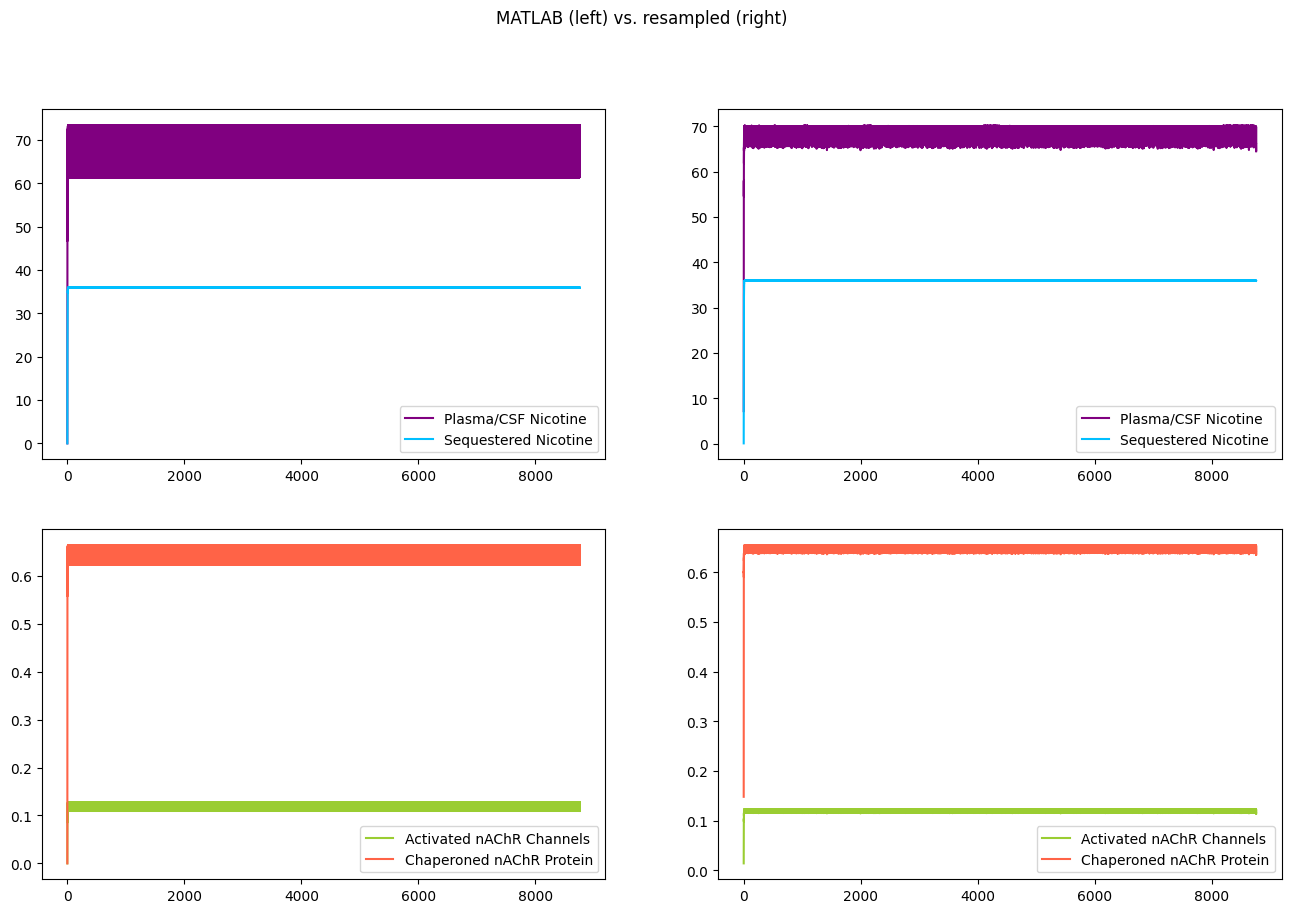

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0, 0].plot(df_sh['Time'], df_sh['Plasma/ CSF/ ER Nicotine'], label='Plasma/CSF Nicotine', color='purple')
axs[0, 0].plot(df_sh['Time'], df_sh['Sequestered Nicotine'], label='Sequestered Nicotine', color='deepskyblue')


axs[1, 0].plot(df_sh['Time'], df_sh['Fraction of Activated nAChR'], label='Activated nAChR Channels', color='yellowgreen')
axs[1, 0].plot(df_sh['Time'], df_sh['Fraction of Chaperoned nAChR'], label='Chaperoned nAChR Protein', color='tomato')


axs[0, 1].plot(df_rs['Time'], df_rs['Plasma/ CSF/ ER Nicotine'], label='Plasma/CSF Nicotine', color='purple')
axs[0, 1].plot(df_rs['Time'], df_rs['Sequestered Nicotine'], label='Sequestered Nicotine', color='deepskyblue')


axs[1, 1].plot(df_rs['Time'], df_rs['Fraction of Activated nAChR'], label='Activated nAChR Channels', color='yellowgreen')
axs[1, 1].plot(df_rs['Time'], df_rs['Fraction of Chaperoned nAChR'], label='Chaperoned nAChR Protein', color='tomato')


for i in range(2):
    for j in range(2):
        handles, labels = axs[i, j].get_legend_handles_labels()
        if labels:
            axs[i, j].legend()

plt.suptitle('MATLAB (left) vs. resampled (right)')
plt.show()